# Autograd: The building block (or node) of deep learning

The idea of a neural network has been fundamental to making modern AI possible since McCulloch and Pitts in 1943. The universal approximation theorem proved a single hidden-layer, arbitrarily wide MLP (multi-layer perceptron) with non-linearity can be a universal approximator. However, what made MLPs possible was the idea of backpropagation: that weights in a network can continuously learn.

A section will cover this algorithm, but backpropagation hinges on being able to differentiate through a neural network. To do this, we construct our own version of what is present-day PyTorch. The `Value` class will allow us to automatically differentiate through a network with respect to each variable.

In [3]:
%pip install graphviz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
import math
from graphviz import Digraph

First, a helper function we will use to represent the physical nature of these nodes.

In [52]:
from graphviz import Digraph

def draw_graph(root):
  dot = Digraph(format='png', graph_attr={'rankdir': 'LR'})
  visited = set()

  def build(v):
    if v in visited:
      return
    visited.add(v)

    dot.node(
      str(id(v)),
      f"{v.name}\nval={v.val}\ngrad={v.grad}",
      shape='box'
    )

    for child in v.children:
      build(child)
      dot.edge(str(id(child)), str(id(v)))

  build(root)
  return dot

In [150]:
class Value:

  def __init__(self, val:float, name:str = "", children:set = set()):
    self.val = val
    self.grad = 0
    self._backprop = lambda: None
    self.name = name
    self.children = children
  def __repr__(self):
    return self.name + ": " + str(self.val)

  def __add__(self, other):
    if not isinstance(other, Value):
      other = Value(other)
    res =  Value(self.val + other.val, f"({self.name}+{other.name})", set([self, other]))

    def _backprop():
      self.grad += res.grad
      other.grad += res.grad

    res._backprop = _backprop
    return res
  
  def __radd__(self, other):
    return self + other
  
  def __rmul__(self, other):
    return self * other
  
  def __neg__(self):
    return -1 * self
  
  def __sub__(self, other):
    return self + (-other)
  
  def __mul__(self, other):
    if not isinstance(other, Value):
      other = Value(other)
    res = Value(self.val * other.val, f"({self.name}*{other.name})", set([self, other]))

    def _backprop():
      self.grad += res.grad * other.val
      other.grad += res.grad * self.val

    res._backprop = _backprop
    return res
  
  def __pow__(self, other):
    if isinstance(other, float) or isinstance(other, int):
      other = Value(other)

    res = Value(self.val ** other.val, f"({self.name}^{other.name})", set([self, other]))

    def _backprop():
      self.grad += other.val * self.val ** (other.val - 1) * res.grad

    res._backprop = _backprop
    return res
  
  def __truediv__(self, other):
    return self * other ** (-1)
  
  def exp(self):
    res = Value(math.e ** self.val, f"(e^{self.name})", set([self]))

    def _backprop():
      self.grad += math.e ** self.val * res.grad
    res._backprop = _backprop
    return res
  
  def tanh(self):
    x = self.val
    res = Value(((math.e**x - math.e**(-x)) / (math.e**x + math.e**(-x))), f"tanh({self.name})", set([self]))

    def _backprop():
      self.grad += (1 - (res.val)**2) * res.grad

    res._backprop = _backprop
    return res

In [74]:
a = Value(2, "a")
b = Value(3, "b")

In [67]:
a + b

(a+b): 5

In [68]:
-a

(-a): -2

In [69]:
a - b

(a+(-b)): -1

In [135]:
## Example network

a = Value(2.5, "a")
b = Value(1.5, "b")
c = Value (1, "c")
d = Value (0.5, "d")

x1 = a * b; x1.name = "x1"
x2 = c * d; x2.name = "x2"

x3 = x1 + x2; x3.name = "x3"
e = Value(1, "e")
b = (x3 + e)**2; b.name = "b"

L = b.tanh()

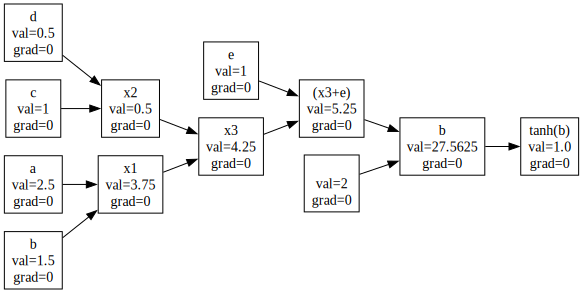

In [118]:
draw_graph(L)

## Now we must figure out what the derivatives are at each step

$$L = tanh(b) = 1$$

$$\frac{\partial L}{\partial L} = 1$$

$$\frac{\partial L}{\partial b} = \frac{\partial}{\partial b} tanh(b) = 1 - tanh(b)^2$$

For example's sake, call x3 + e = y, then $$\frac{\partial b}{\partial y} = \frac{\partial}{\partial b} y^2 = 2y$$

Then  $$\frac{\partial y}{\partial x_3} = \frac{\partial y}{\partial e} = 1$$

$$\frac{\partial x_3}{\partial x_2} = \frac{\partial x_3}{\partial x_1} = 1$$

Using the product rule, $$\frac{\partial x_2}{\partial c} = d$$

$$\frac{\partial x_2}{\partial d} = c$$

$$\frac{\partial x_1}{\partial a} = b$$

$$\frac{\partial x_1}{\partial b} = a$$

Let's add in the computation of gradients in the Value class and call each of these gradients manually first. Next, we will define a function to automatically differentiate through this computation graph.

In [136]:
L.grad = 1.0
L._backprop()   # pushes grad to b
b._backprop()   # pushes grad to x3 and e
x3._backprop()  # pushes grad to x1 and x2
x2._backprop()  # pushes grad to c and d
x1._backprop()  # pushes grad to a and b

In [ ]:
print('L.grad =', L.grad)
print('b.grad =', b.grad)
print('x3.grad =', x3.grad)
print('x2.grad =', x2.grad)
print('x1.grad =', x1.grad)
print('a.grad =', a.grad)
print('b input grad =', b.grad)
print('c.grad =', c.grad)
print('d.grad =', d.grad)
print('e.grad =', e.grad)

L.grad = 1.0
b.grad = 0.0
x3.grad = 0
x2.grad = 0
x1.grad = 0
a.grad = 0.0
b input grad = 0.0
c.grad = 0.0
d.grad = 0
e.grad = 0


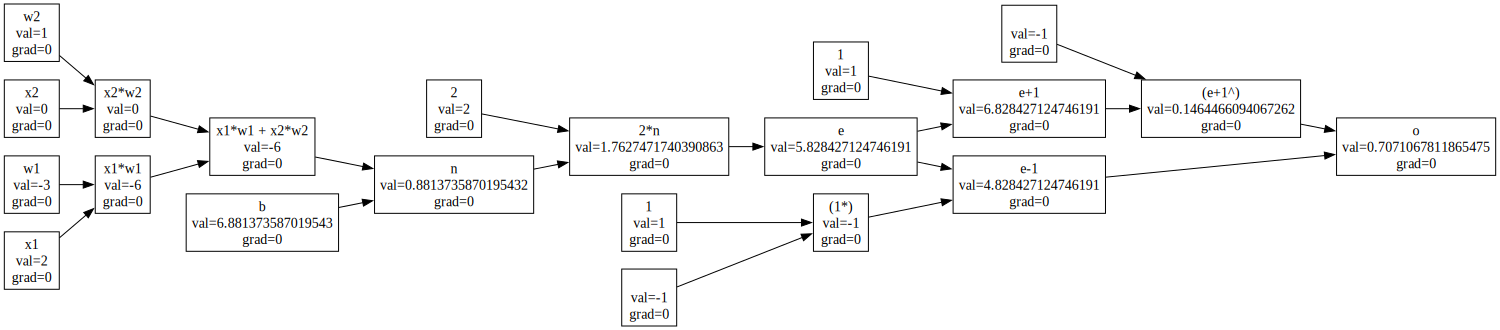

In [153]:
# inputs x1 x2
x1 = Value(2, name='x1')
x2 = Value(0, name='x2')
w1 = Value(-3, name='w1')
w2 = Value(1, name='w2')
b = Value(6.8813735870195432, name='b')

x1w1 = x1 * w1; x1w1.name = 'x1*w1'
x2w2 = x2 * w2; x2w2.name = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.name = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.name = 'n'

two = Value(2, name='2')
e_input = two * n; e_input.name = '2*n'
e = e_input.exp(); e.name = 'e'

one1 = Value(1, name='1')
one2 = Value(1, name='1')

num = e - one1; num.name = 'e-1'
den = e + one2; den.name = 'e+1'
o = num / den; o.name = 'o'
draw_graph(o)

In [154]:
o.grad = 1.0

o._backprop()          # pushes to num and den
den._backprop()        # pushes to e and one2
num._backprop()        # pushes to e and one1
e._backprop()          # pushes to e_input
e_input._backprop()    # pushes to two and n
n._backprop()          # pushes to x1w1x2w2 and b
x1w1x2w2._backprop()   # pushes to x1w1 and x2w2
x2w2._backprop()       # pushes to x2 and w2
x1w1._backprop()       # pushes to x1 and w1

In [155]:
print('o.grad   =', o.grad)
print('num.grad =', num.grad)
print('den.grad =', den.grad)
print('e.grad   =', e.grad)
print('n.grad   =', n.grad)
print('x1w1x2w2.grad =', x1w1x2w2.grad)
print('x1w1.grad =', x1w1.grad)
print('x2w2.grad =', x2w2.grad)
print('x1.grad   =', x1.grad)
print('x2.grad   =', x2.grad)
print('w1.grad   =', w1.grad)
print('w2.grad   =', w2.grad)
print('b.grad    =', b.grad)

o.grad   = 1.0
num.grad = 0.1464466094067262
den.grad = 0
e.grad   = 0.1464466094067262
n.grad   = 1.7071067811865475
x1w1x2w2.grad = 1.7071067811865475
x1w1.grad = 1.7071067811865475
x2w2.grad = 1.7071067811865475
x1.grad   = -5.121320343559642
x2.grad   = 1.7071067811865475
w1.grad   = 3.414213562373095
w2.grad   = 0.0
b.grad    = 1.7071067811865475


## Now we define a backprop function which sets the output gradient to 1 and does all of this automatically

- Order computation graph from root (make topological sort)
- Compute each successive gradient

In [1]:
def backprop(root):
  root.grad = 1

  topo_lst = []
  visited = set()

  def topo(cur):
    if cur in visited:
      return
    
    visited.add(cur)
    for node in cur.children:
      topo(node)
    topo_lst.append(cur)

  topo(root)

  for node in reversed(topo_lst):
    node._backprop()

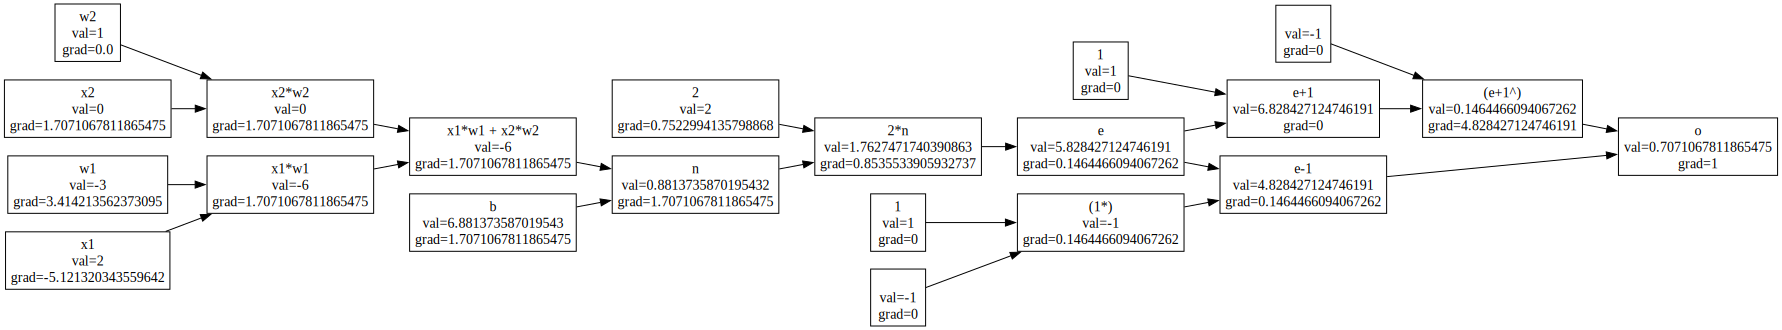

In [169]:
draw_graph(o)